In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as scp

# Input parameters
# Nacelle
Mass_RNA = 350000             # [kg]

# tower
H_Tower = 80                    # [m]
m_Tower = 347500/H_Tower                   # [kg/m]
D_avg=(6.5 + 3.87) / 2        # [m]
t_avg = (0.027 + 0.019) / 2       # [m]
A = np.pi * D_avg * t_avg          # [m2]
I = np.pi * D_avg**3 * t_avg / 8  # [m4]
E = 210e9                       # [N/m2]
EI_Tower = E * I                 # [N.m2]
EA_Tower = E * A                 # [N]


#spar 
M_spar = 7466330                # [kg]
I_spar = 4229230000                 # [kg.m2]




#wave parameters
H_Wave = 6.0 #[m]
T_wave = 10.0 #[s]
T_total = 200.0  #[s]

#time vector
dt= 0.05
T = np.arange(0, T_total, dt)
nT = len(T)




discretize the domain 

In [26]:
# Define node coordinates
 
n_elem = 40 
n_nodes = n_elem + 1

tower_nodes = np.array([[0, y] for y in np.linspace(0, H_Tower, n_nodes)])

spar_node = np.array([[0, -99.9]])

NodeCoord = np.vstack([spar_node, tower_nodes])
nNode = len(NodeCoord)

In [27]:
# Define elements (and their properties
#             NodeLeft    NodeRight          m         EA        EI
Elements = []
for i in range (1, n_nodes):
    Elements.append([i, i+1, m_Tower, EA_Tower, EI_Tower])

Elements = np.array(Elements)
nElem = len(Elements)


plot the structure 

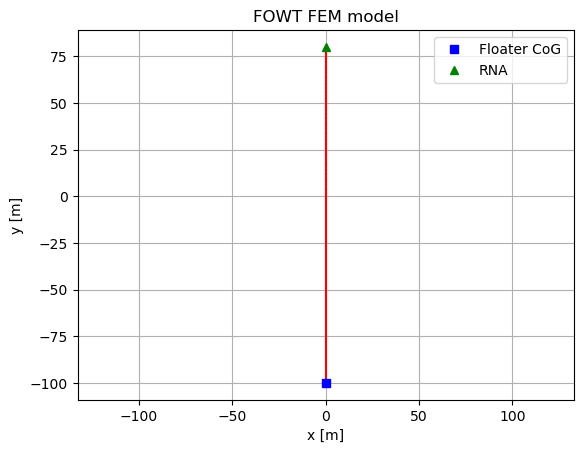

In [28]:
plt.figure()
for iElem in np.arange(0, nElem):
    NodeLeft = int(Elements[iElem][0])-1
    NodeRight = int(Elements[iElem][1])-1
    plt.plot([NodeCoord[NodeLeft][0], NodeCoord[NodeRight][0]], [NodeCoord[NodeLeft][1], NodeCoord[NodeRight][1]], 'r')

plt.plot(NodeCoord[0][0], NodeCoord[0][1], 'bs', label='Floater CoG')
plt.plot(NodeCoord[-1][0], NodeCoord[-1][1], 'g^', label='RNA')
plt.legend()
plt.axis('equal')
plt.grid()
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('FOWT FEM model')
plt.show()

Shape functions: 

In [29]:
nDof = 3*nNode              # 3 Degrees of freedom per node
K = np.zeros((nDof, nDof))
M = np.zeros((nDof, nDof))

In [30]:
for iElem in range(nElem):
    # Get the nodes of the elements
    NodeLeft = int(Elements[iElem][0])-1
    NodeRight = int(Elements[iElem][1])-1

    m = Elements[iElem][2]
    EA = Elements[iElem][3]
    EI = Elements[iElem][4]

    x1,y1 = NodeCoord[NodeLeft]
    x2,y2 = NodeCoord[NodeRight]
    L = np.sqrt((x2-x1)**2 + (y2-y1)**2)

    #elemental stiffness matrix

    Ke = np.array([
            [ EA/L,           0,          0, -EA/L,           0,          0],
            [    0,  12*EI/L**3,  6*EI/L**2,     0, -12*EI/L**3,  6*EI/L**2],
            [    0,   6*EI/L**2,    4*EI/L,      0,  -6*EI/L**2,    2*EI/L ],
            [-EA/L,           0,          0,  EA/L,           0,          0],
            [    0, -12*EI/L**3, -6*EI/L**2,    0,  12*EI/L**3, -6*EI/L**2],
            [    0,   6*EI/L**2,    2*EI/L,     0,  -6*EI/L**2,    4*EI/L ]
        ])
    
    #elemental mass matrix 
    Me = m * L / 420 * np.array([
        [140,          0,         0,  70,          0,         0],
        [  0,        156,    22*L,    0,         54,    -13*L ],
        [  0,       22*L,   4*L**2,   0,       13*L,  -3*L**2 ],
        [ 70,          0,         0, 140,          0,         0],
        [  0,         54,     13*L,   0,        156,    -22*L ],
        [  0,      -13*L,  -3*L**2,   0,      -22*L,   4*L**2 ]
    ])

    # Get the degrees of freedom that correspond to each node
    Dofs_Left = 3*(NodeLeft) + np.arange(0, 3)
    Dofs_Right = 3*(NodeRight) + np.arange(0, 3)
    nodes = np.append(Dofs_Left, Dofs_Right)

    # Assemble the matrices at the correct place
    for i in np.arange(0, 6):
        for j in np.arange(0, 6):
            K[nodes[i], nodes[j]] += Ke[i, j]
            M[nodes[i], nodes[j]] += Me[i, j]

#add floater
M[0, 0] += M_spar
M[1, 1] += M_spar
M[2, 2] += I_spar


#add RNA point mass
I_RNA = 115926000  # [kg·m²] from OC3
M[3*n_nodes+2, 3*n_nodes+2] += I_RNA

M[3*n_nodes, 3*n_nodes] += Mass_RNA
M[3*n_nodes+1, 3*n_nodes+1] += Mass_RNA


In [31]:
print("Mass matrix M:")
print(M)
print("Stiffness matrix K:")
print(K)


Mass matrix M:
[[7.61097688e+06 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 7.62750795e+06 2.27074930e+06 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.27074930e+06 4.27047506e+09 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 3.50000000e+05
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  3.50000000e+05 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 1.15926000e+08]]
Stiffness matrix K:
[[7.87553881e+08 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 3.18227773e+06 1.58954773e+08 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.58954773e+08 1.05863879e+10 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+

Text(0.5, 1.0, 'Stiffness matrix')

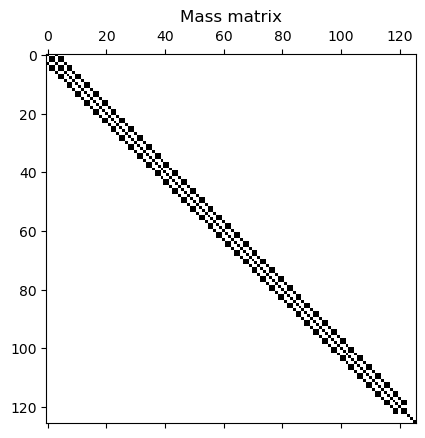

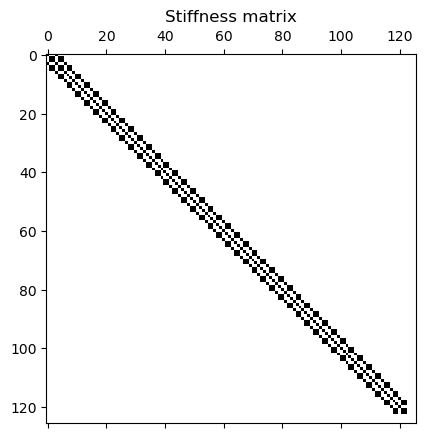

In [32]:
# Look at the matrix structure
plt.figure()
plt.spy(M)
plt.title("Mass matrix")
plt.figure()
plt.spy(K)
plt.title("Stiffness matrix")

In [33]:
#hydrostatic stiffness

rho_water = 1025 # [kg/m3]
gravity = 9.81 # [m/s2]
pi = 3.141592

# hydrostatic restoring stiffness
# Substructure Definitions
r_spar = 4.7  # Substructure Radius, assumed constant throughout
A_spar = pi * r_spar**2  # Cross-sectional area of the substructure
L_spar = 120 + 10  # Spar Buoy Length


draft_s = 120
submerged_volume_s = A_spar * draft_s
KBuoyancy_s = 120 - 62.06 
J_sub = np.pi/64 * r_spar**4
BM_s = J_sub / submerged_volume_s
KGravity_s = 120-89.9
GM_s = KBuoyancy_s + BM_s - KGravity_s #metacentric height 

k_hydro_heave  = rho_water * gravity * A_spar

k_hydro_pitch =   rho_water * gravity * submerged_volume_s * GM_s  #[N/m]

print(f"GM = {GM_s} m")
print("Hydrostatic stiffness in heave: ", k_hydro_heave, "N/m")
print("Hydrostatic stiffness in pitch: ", k_hydro_pitch, "N.m/rad")

GM = 27.842876302681738 m
Hydrostatic stiffness in heave:  697811.8994422201 N/m
Hydrostatic stiffness in pitch:  2331490847.8450947 N.m/rad


In [41]:
# Mooring and hydrostatic stiffness
k_moor_surge = 41853
k_moor_heave = 0
k_moor_pitch = 98340000       # [N.m/rad] from OC3

# Add to floater node (DOFs 0,1,2)
K[0,0] += k_moor_surge
K[1,1] += k_hydro_heave + k_moor_heave
K[2,2] += k_hydro_pitch + k_moor_pitch

# Add to tower base node (DOFs 3,4,5) — kinematically linked via T_link
K[3,3] += k_moor_surge
K[4,4] += k_hydro_heave + k_moor_heave
K[5,5] += k_hydro_pitch + k_moor_pitch

# T_link: couple floater and tower base off-diagonal blocks
h = 99.9
T_link = np.array([[1, 0, h],
                   [0, 1, 0],
                   [0, 0, 1]])
floater_dofs   = np.array([0, 1, 2])
towerbase_dofs = np.array([3, 4, 5])

K[np.ix_(floater_dofs, towerbase_dofs)] = T_link.T @ K[np.ix_(towerbase_dofs, towerbase_dofs)]
K[np.ix_(towerbase_dofs, floater_dofs)] = K[np.ix_(towerbase_dofs, towerbase_dofs)] @ T_link

M[np.ix_(floater_dofs, towerbase_dofs)] = T_link.T @ M[np.ix_(towerbase_dofs, towerbase_dofs)]
M[np.ix_(towerbase_dofs, floater_dofs)] = M[np.ix_(towerbase_dofs, towerbase_dofs)] @ T_link

In [42]:
print("Mass matrix M after adding mooring and hydrostatic stiffness:")
print(M)
print("Stiffness matrix K after adding mooring and hydrostatic stiffness:")
print(K)

Mass matrix M after adding mooring and hydrostatic stiffness:
[[7.61097688e+06 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 7.62750795e+06 2.27074930e+06 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.27074930e+06 4.27047506e+09 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 3.50000000e+05
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  3.50000000e+05 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 1.15926000e+08]]
Stiffness matrix K after adding mooring and hydrostatic stiffness:
[[7.87637587e+08 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 4.57790153e+06 1.58954773e+08 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.58954773e+08 1.53477096e+10 ... 0.00000000e+00
  0.000

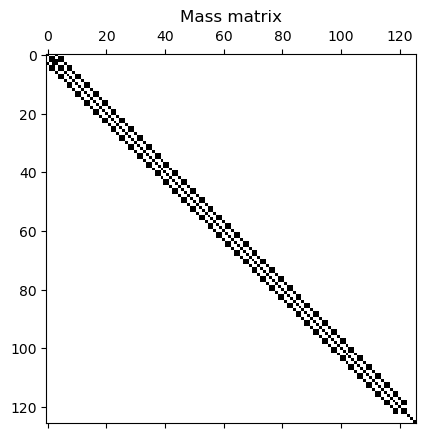

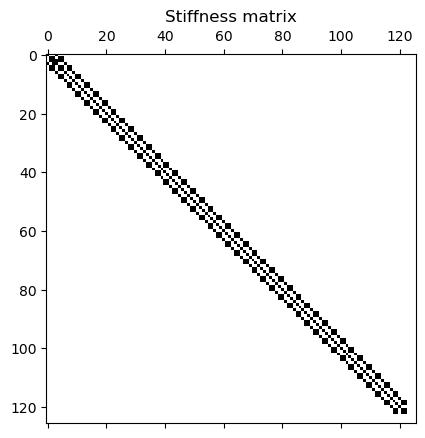

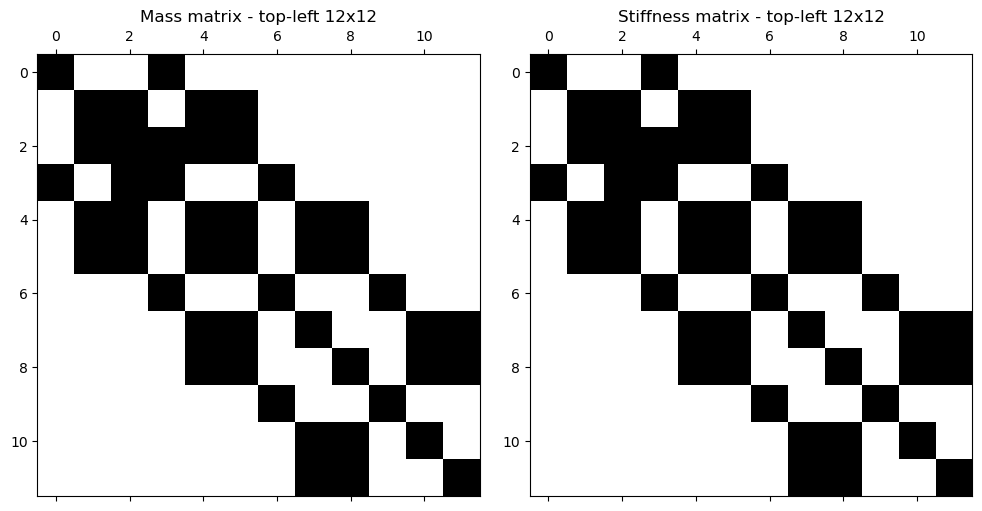

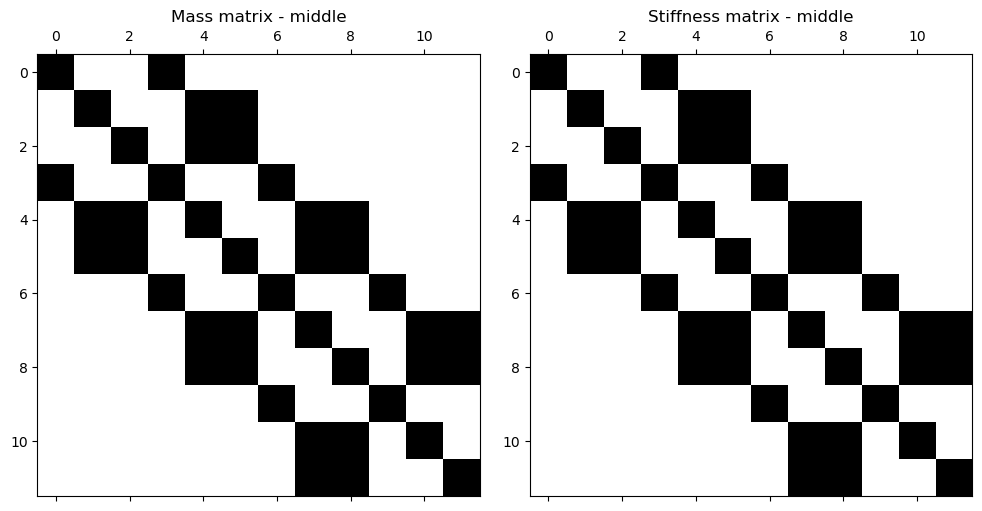

In [43]:
# Look at the matrix structure
plt.figure()
plt.spy(M)
plt.title("Mass matrix")
plt.figure()
plt.spy(K)
plt.title("Stiffness matrix")
# Zoom into top-left corner (floater + tower base coupling)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].spy(M[:12, :12])
axes[0].set_title("Mass matrix - top-left 12x12")
axes[1].spy(K[:12, :12])
axes[1].set_title("Stiffness matrix - top-left 12x12")
plt.tight_layout()
plt.show()


# Zoom into middle (around node 20, middle of tower)
mid = 3 * (nNode // 2)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].spy(M[mid-6:mid+6, mid-6:mid+6])
axes[0].set_title("Mass matrix - middle")
axes[1].spy(K[mid-6:mid+6, mid-6:mid+6])
axes[1].set_title("Stiffness matrix - middle")
plt.tight_layout()
plt.show()

Modal analysis: 

C:\Users\Carolina\AppData\Local\Temp\ipykernel_26684\688066030.py:9: RuntimeWarning: divide by zero encountered in divide
  periods = 1 / freq_Hz


First 5 natural frequencies [Hz]:
[129.33789351  91.81264906   0.           0.           0.        ]

First 5 natural periods [s]:
[0.00773169 0.01089175        inf        inf        inf]


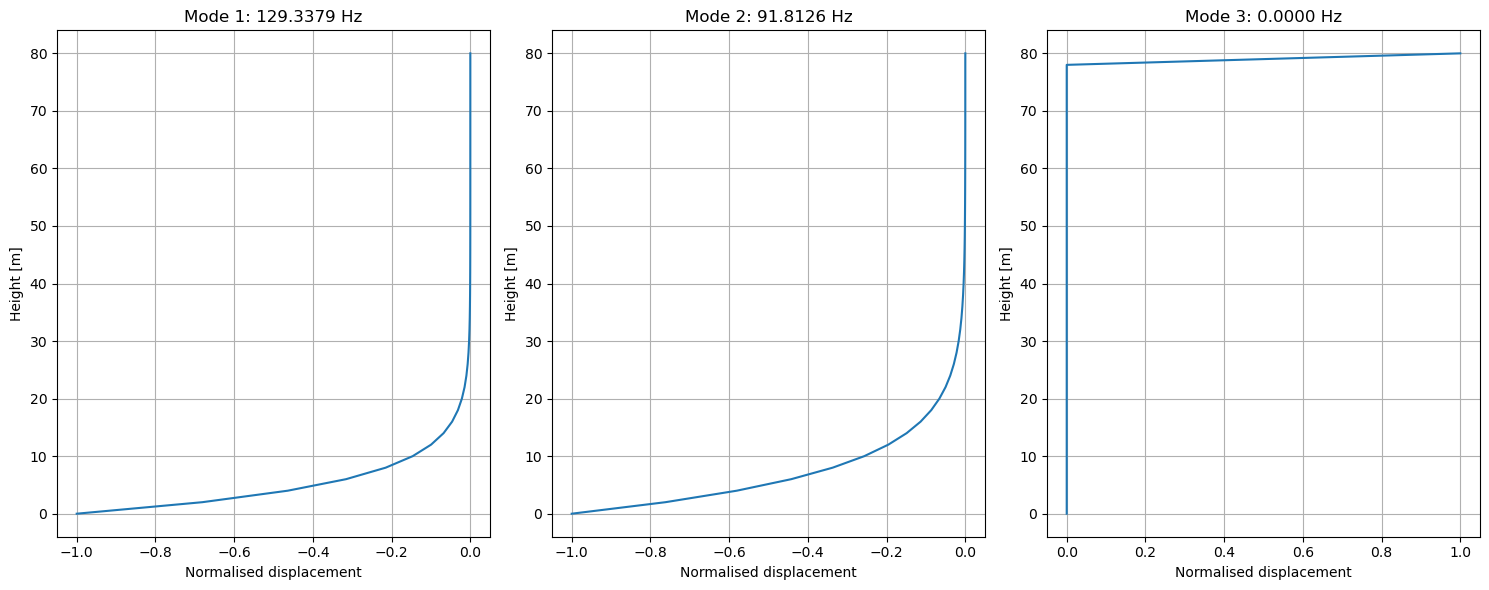

In [44]:
from scipy.linalg import eigh

# Solve generalised eigenvalue problem K*phi = omega^2 * M * phi
eigenvalues, eigenvectors = eigh(K, M)

# Natural frequencies
omega = np.sqrt(np.abs(eigenvalues))
freq_Hz = omega / (2 * np.pi)
periods = 1 / freq_Hz

print("First 5 natural frequencies [Hz]:")
print(freq_Hz[:5])
print("\nFirst 5 natural periods [s]:")
print(periods[:5])

# Plot first 3 mode shapes
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for mode in range(3):
    phi = eigenvectors[:, mode]
    # Extract horizontal displacement DOFs of tower nodes (DOF 0 of each node)
    tower_x_dofs = [3 + 3*i for i in range(n_nodes)]
    tower_y = NodeCoord[1:, 1]  # y-coordinates of tower nodes
    mode_shape = phi[tower_x_dofs]
    mode_shape = mode_shape / np.max(np.abs(mode_shape))  # normalise
    axes[mode].plot(mode_shape, tower_y)
    axes[mode].set_title(f"Mode {mode+1}: {freq_Hz[mode]:.4f} Hz")
    axes[mode].set_xlabel("Normalised displacement")
    axes[mode].set_ylabel("Height [m]")
    axes[mode].grid()

plt.tight_layout()
plt.show()


In [45]:
print("All frequencies [Hz]:", freq_Hz[:20])


All frequencies [Hz]: [129.33789351  91.81264906   0.           0.           0.
   0.49622302   1.49785845   3.13845108   5.65093169  12.85848386
  13.61501716  24.77714938  39.63645886  40.79447103  52.43059646
  60.73497972  70.94692254  84.21137297  97.67529953 109.26235145]


In [46]:
print("K[0,0] surge:", K[0,0])
print("K[1,1] heave:", K[1,1])
print("K[2,2] pitch:", K[2,2])
print("GM:", GM_s)

K[0,0] surge: 787637586.8789656
K[1,1] heave: 4577901.532049034
K[2,2] pitch: 15347709562.276846
GM: 27.842876302681738
